### Techniques
- Temporal
- EGCI
- Autoencoding clustering
- Aux model embeddings (SurfPerch, Perch)
- Banding

In [13]:
# imports

import librosa
from datetime import datetime
import os

from pyha_analyzer import extractors

from utils import *
from models import AutoEncoder

import torch
import pandas as pd
import seaborn as sns
import sklearn

from collections import defaultdict

In [2]:
config = {
    'device': 'cuda',
    'num_dims': 10
}

In [3]:
# rev up the models
autoencoder_model = AutoEncoder(config['num_dims'], "dim_10_muha.pt", config['device'])
# 20240306_071700.WAV
timestamp_match = "%Y%m%d_%H%M%S.WAV"

In [4]:
# preprocessing

music_extractor = extractors.Music()
music_ads = music_extractor('/home/a.jajodia.229/acoustic/local_data/muha')

ds = music_ads['test']

Casting the dataset:   0%|          | 0/5079 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/653 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1524 [00:00<?, ? examples/s]

In [37]:
# template processing

duration = 3

templates_df = pd.read_csv("templates.csv", index_col=0)

template_embeddings = []
template_labels = []

for idx in tqdm(range(len(templates_df))):
    row = templates_df.iloc[idx]
    filename = row['filename']
    filepath = "templates/" + filename
    
    try:
        sample_rate = librosa.get_samplerate(filepath)
    except:
        continue
    
    
    audios = get_audio_split(filepath, duration)
    
    for i, audio in enumerate(audios):
        melspectrogram = get_melspec(audio, sample_rate=sample_rate)
        try:
            autoencoder_embedding = autoencoder_model.embed(torch.tensor(melspectrogram).unsqueeze(0))
        except:
            continue
        
        template_embeddings.append(autoencoder_embedding)
        template_labels.append(row["genus"]+ "_" + row["species"])
        
        

  1%|          | 2/365 [00:00<02:42,  2.24it/s]/tmp/ipykernel_317960/2473951419.py:16: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  sample_rate = librosa.get_samplerate(filepath)
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 3024.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  3%|▎         | 12/365 [00:04<01:39,  3.56it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 3024.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
/tmp/ipykernel_317960/2473951419.py:16: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  sample_rate = librosa.get_samplerate(filepath)
  4%|▍         | 14/365 [00:04<01:04,  5.48it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 3024.
Note: Trying to resync...
/tmp/ipykernel_317960/24739514

In [6]:
# main processing loop

duration = 3

results = []

individual_labels = []

for idx in tqdm(range(100)):
    row = ds[idx]
    filepath = row['filepath']
    sample_rate = row['sample_rate']
    filename = os.path.basename(filepath)
    
    extra_labels = {key:row[key] for key in individual_labels}
    extra_labels['location'] = filepath.split('/')[6]
    
    audios = get_audio_split(filepath, duration)
    
    # timestamp = datetime.strptime(filename, timestamp_match)
    
    # print(timestamp)
    
    for i, audio in enumerate(audios):
        melspectrogram = get_melspec(audio, sample_rate=sample_rate)
        
        entropy, complexity = EGCI(audio, 256)
        
        # surfperch_embedding = 
        
        autoencoder_embedding = autoencoder_model.embed(torch.tensor(melspectrogram).unsqueeze(0))
        
        autoencoder_embedding_vals = {"ae"+str(i):autoencoder_embedding[i] for i in range(config["num_dims"])}
        
        result = {
            "entropy": entropy,
            "complexity": complexity,
            "chunk_num": i
        }
        result.update(extra_labels)
        result.update(autoencoder_embedding_vals)
        
        results.append(result)

  0%|          | 0/100 [00:00<?, ?it/s]/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
  1%|          | 1/100 [00:01<01:40,  1.01s/it]/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
  2%|▏         | 2/100 [00:01<00:58,  1.66it/s]/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filte

In [7]:
df = pd.DataFrame.from_records(results)
# df["isDegraded"] = df['labels'].astype(str) == "[1, 0]"

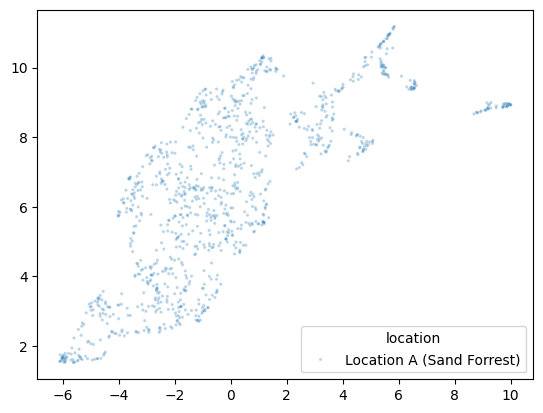

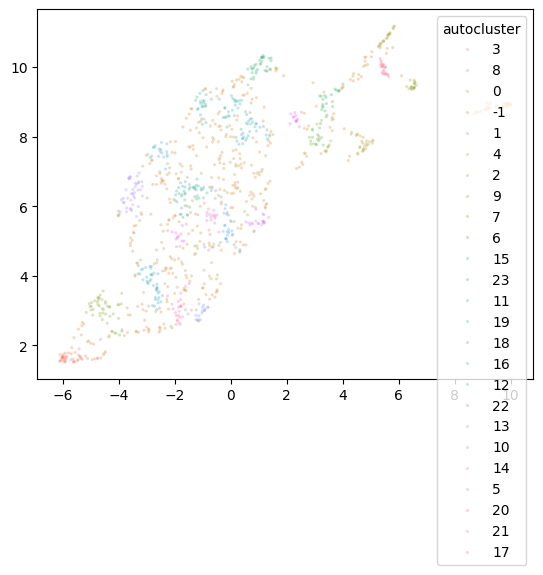

In [38]:
# clustering by autoencoding
from sklearn.preprocessing import StandardScaler

import umap

reducer = umap.UMAP()
autoarray = StandardScaler().fit_transform(df[[s for s in df.columns.to_list() if "ae" in s]].to_numpy())

# autoarray = sklearn.manifold.TSNE(n_components=3).fit_transform(df[[s for s in df.columns.to_list() if "ae" in s]].to_numpy())
auto_reduced = reducer.fit_transform(autoarray)


sns.scatterplot(x=auto_reduced[:, 0], y=auto_reduced[:, 1], hue=df['location'], s=5, alpha=0.3)
plt.show()

clustering = sklearn.cluster.HDBSCAN(min_cluster_size=len(df)//100, max_cluster_size=len(df)//10).fit_predict(auto_reduced)

df["autocluster"] = clustering
df["autocluster"] = df["autocluster"].astype(str)

sns.scatterplot(x=auto_reduced[:, 0], y=auto_reduced[:, 1], hue=df['autocluster'], s=5, alpha=0.3)
plt.show()


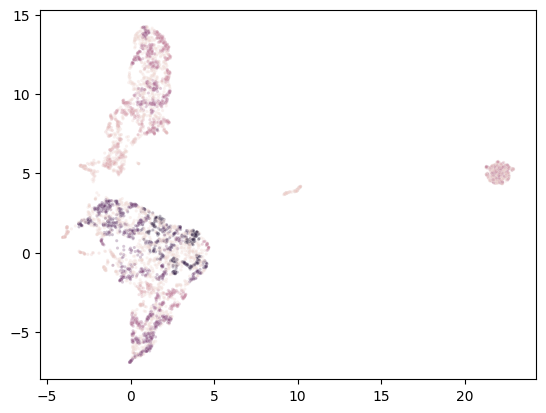

In [45]:
template_array = StandardScaler().fit_transform(np.array(template_embeddings))

# autoarray = sklearn.manifold.TSNE(n_components=3).fit_transform(df[[s for s in df.columns.to_list() if "ae" in s]].to_numpy())
template_reduced = reducer.fit_transform(template_array)


clustering = sklearn.cluster.HDBSCAN(min_cluster_size=len(df)//100, max_cluster_size=len(df)//10).fit_predict(auto_reduced)

sns.scatterplot(x=template_reduced[:, 0], y=template_reduced[:, 1], hue=clustering, s=5, alpha=0.3)
plt.legend().remove()


100%|██████████| 1081/1081 [00:01<00:00, 689.02it/s]


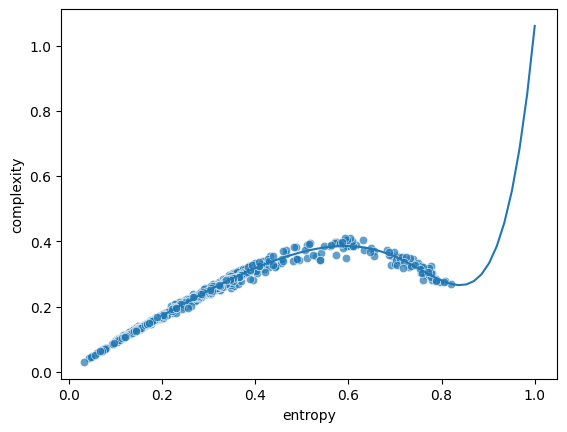

In [9]:
# clustering (we hardcode cluster values until we actually have a better way to cluster)
# using spectral clustering from Scikit-learn
from scipy.optimize import minimize

# clustering = sklearn.cluster.SpectralClustering(n_clusters=5,
#         assign_labels='discretize',
#         random_state=0).fit(df[["entropy", "complexity"]])

# df['egci_clusters'] = clustering.labels_
# sns.scatterplot(x=df["entropy"], y=df["complexity"], hue=df['egci_clusters'], alpha=0.7)
# plt.show()

points = np.array([df["entropy"], df["complexity"]]).T

f = np.poly1d(np.polyfit(points[:, 0], points[:, 1],7))

sns.scatterplot(x=df["entropy"], y=df["complexity"], 
                # hue=df['egci_clusters'],
                alpha=0.7)
plt.plot(np.linspace(0.2, 1).reshape(-1,1), f(np.linspace(0.2, 1)).reshape(-1,1))


dist = []
for point in tqdm(points):
    # Function to minimize: squared distance
    def squared_distance(x):
        return sum((x - point[0])**2 + (f(x) - point[1])**2)

    # Initial guess for x (can be important for convergence)
    x0 = 0.5 # A reasonable starting point

    # Use a numerical optimizer to find the x that minimizes the squared distance
    result = minimize(squared_distance, x0)

    delta_y = np.sqrt(result.fun)
    
    if f(result.x[0]) < point[1] :
        dist.append(delta_y)
    else:
        dist.append(delta_y * -1)
dist = np.array(dist)

In [10]:
normalize = lambda e: (e-e.min())/(e.max()-e.min())

# normalize = lambda e: e

In [11]:
import plotly.express as px

egci_points = StandardScaler().fit_transform(np.concat([points[:,0].reshape(-1,1), points[:,1].reshape(-1,1), normalize(dist.reshape(-1,1))], axis=1))
egci_points = reducer.fit_transform(egci_points)



sns.scatterplot(x=egci_points[:, 0], y=egci_points[:, 1], hue=df['isDegraded'], s=5, alpha=0.5)
plt.show()


clustering = sklearn.mixture.BayesianGaussianMixture(n_components=10).fit_predict(egci_points)


df['egci_clusters'] = clustering.astype(str)

sns.scatterplot(x=egci_points[:, 0], y=egci_points[:, 1], hue=df['egci_clusters'], s=5, alpha=0.5)
plt.show()

KeyError: 'isDegraded'

In [ ]:
df.to_csv("output.csv")